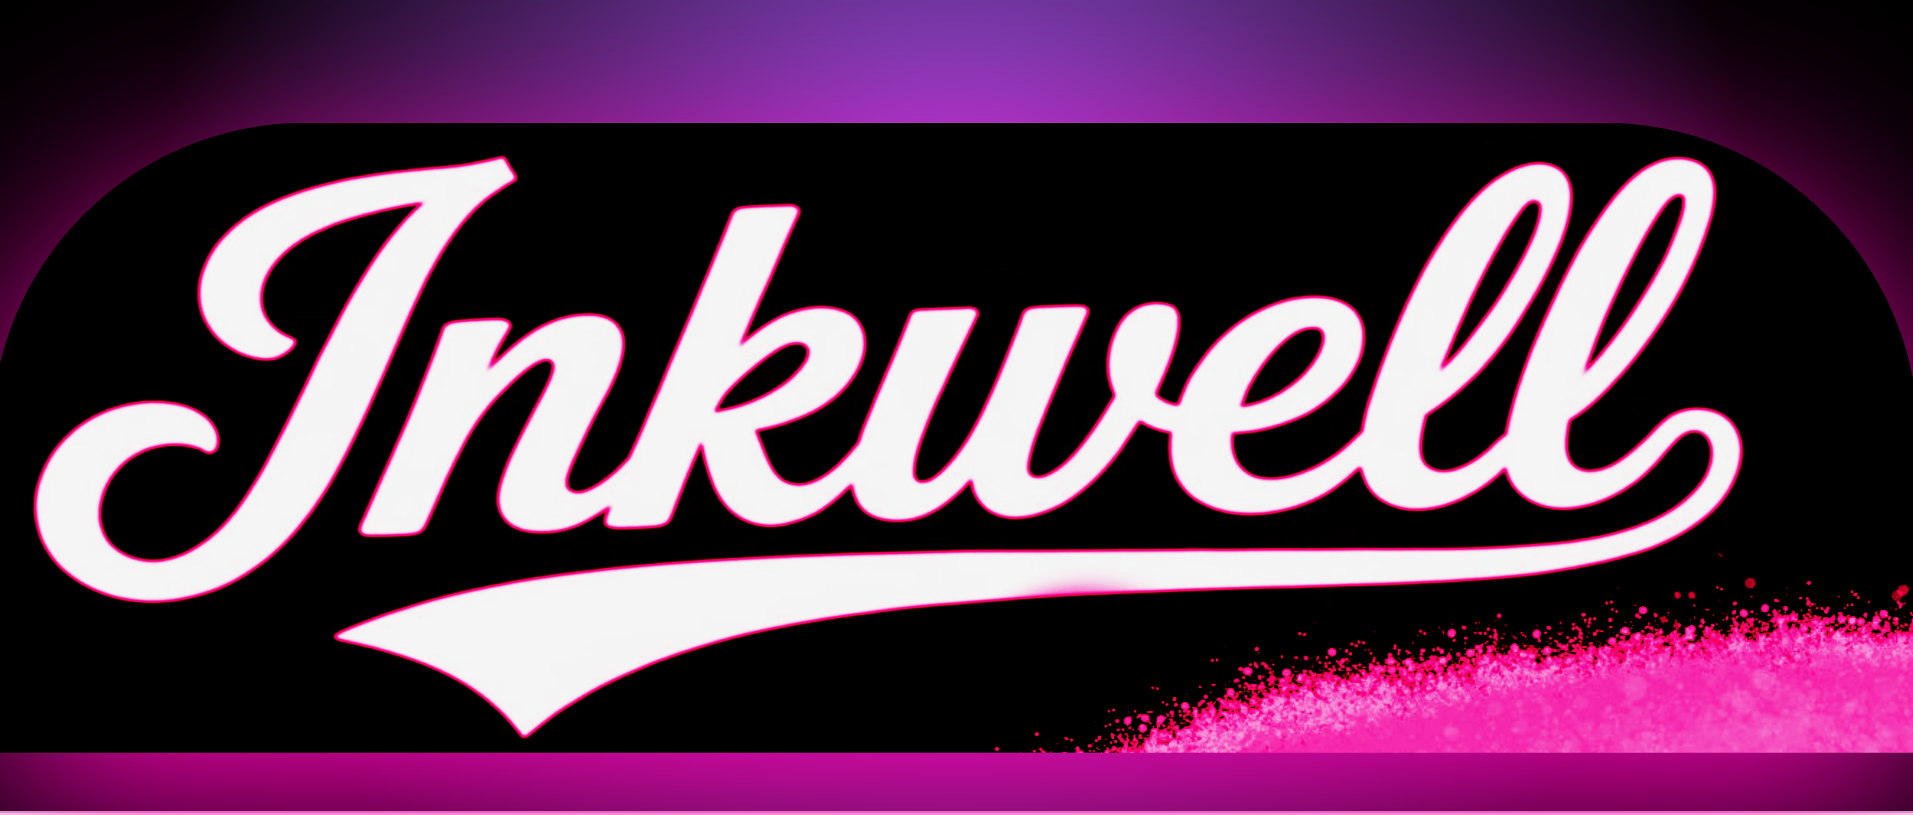

# **Inkwell: Project Overview**
**Computer Vision for Tattoo Aftercare**

The Inkwell Project utilizes a Convolutional Neural Network (CNN) to categorize tattoo recovery into three distinct states: Healthy (Fully healed), Healing Normally (Expected scabbing/peeling), and Unhealthy (Signs of infection, blowouts, or allergic reactions).

# 1. 🤔 Data Challenges & Preprocessing 🤔

Tattoo images present unique challenges for computer vision:

Skin Tone Diversity: The model must be trained on a wide variety of Fitzpatrick skin types to avoid algorithmic bias.

Style Variation: Distinguishing between "redness" from a fresh traditional tattoo and "redness" from an infection.

Lighting and Blur: Users often take photos in suboptimal lighting.

Preprocessing: Images should be resized (e.g., $224 \times 224$), normalized, and augmented with random rotations/flips to improve generalization.

# 2. 🏗️ Proposed CNN Architecture 🏗️

For this classification task, a Transfer Learning approach using EfficientNet-B0 or ResNet-50 is recommended due to their sophisticated feature extraction capabilities.

Layer Logic

Input Layer: $224 \times 224 \times 3$ RGB image.

Base Model: Pre-trained weights (ImageNet) to identify basic shapes and textures.

Global Average Pooling: Reducing spatial dimensions while retaining critical features.

Dense Layer: 256 neurons with ReLU activation and Dropout ($0.5$) to prevent overfitting.

Output Layer: 3 neurons with Softmax activation to provide probability scores for each class.

# 3. 🔮 Classification Categories 🔮

**Healthy**:

Visual Indicators: Smooth texture, settled ink, no inflammation.

Model Focus: Edge sharpness, skin uniformity.

**Healing**:

Visual Indicators: Flaking, "milkskin" appearance, mild redness.

Model Focus: Texture variance, localized crusting.

**Unhealthy**:

Visual Indicators: Pus (yellow/green), extreme swelling, red streaks.

Model Focus: Color histograms (R-channel), irregular borders.

# 4. 🏆 Performance Metrics 🏆

Since "Unhealthy" (Infection) is a medical concern, the model cannot rely on accuracy alone:

Recall (Sensitivity): Crucial for the "Unhealthy" class. We want to minimize False Negatives (missing an infection).

Precision: Ensuring we don't cause unnecessary alarm for normal healing.

F1-Score: The balance between precision and recall across all three classes.

# 5. 🔀 Implementation Roadmap 🔀

Data Collection: Partner with artists to gather labeled "healing" vs. "infected" photos.

Training: Use a Categorical Cross-Entropy loss function.

Deployment: A mobile-first web app where users can upload daily photos to track progress.

# Libraries and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import pandas as pd

from google.colab import drive

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.data import Dataset
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW, Adam
from tensorflow.keras.applications import EfficientNetB0, efficientnet, mobilenet_v2

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_SEED: int = 42

tf.random.set_seed(RANDOM_SEED)

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# --- 1. CONFIGURATION ---
# Adjust these based on your specific dataset
IMG_HEIGHT = 224 # MobileNetV2 standard
IMG_WIDTH = 224
BATCH_SIZE = 32
# 1. Mount Google Drive
# This will prompt you to click a link and authorize access
drive.mount('/content/drive')

# 2. Define the Colab-specific path
# In Colab, your "My Drive" folder is located at: /content/drive/MyDrive/
# Assuming you uploaded the 'InkWell' folder to the root of your Google Drive:
DATA_PATH = "/content/drive/MyDrive/InkWell/CNN/image_database/raw"

NUM_CLASSES = 2 # Update to your number of categories

# --- 2. DATA LOADING & AUGMENTATION ---
# This creates the datasets and handles resizing automatically
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int' # Use 'int' for sparse_categorical_crossentropy
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Optional: Data Augmentation to prevent overfitting
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Performance optimization: Prefetch data into memory
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- 3. MODEL ARCHITECTURE ---
# Load MobileNetV2 with pre-trained ImageNet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model to preserve learned features
base_model.trainable = False

# Build the final model
model = models.Sequential([
    # Explicit Input layer
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Apply data augmentation (only active during training)
    data_augmentation,

    # Preprocessing specific to MobileNetV2 (scales pixels to [-1, 1])
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    # The pre-trained base
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Regularization
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# --- 4. COMPILATION ---
# Using AdamW as requested
model.compile(
    optimizer=optimizers.AdamW(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- 5. TRAINING ---
# Early stopping to prevent wasting time and overfitting
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=[es]
)

# --- 6. OPTIONAL: FINE TUNING ---
# After initial training, you can unfreeze the top layers of the base model
# to achieve higher accuracy.
"""
base_model.trainable = True
# Only train the last few layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-5), # Much lower learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, epochs=10, validation_data=val_ds)
"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 382 files belonging to 2 classes.
Using 306 files for training.
Found 382 files belonging to 2 classes.
Using 76 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5741 - loss: 0.7818 - val_accuracy: 0.6579 - val_loss: 0.6876
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6082 - loss: 0.6793 - val_accuracy: 0.7237 - val_loss: 0.6432
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6591 - loss: 0.6717 - val_accuracy: 0.7237 - val_loss: 0.5922
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6273 - loss: 0.6734 - val_accuracy: 0.7368 - val_loss: 0.5709
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7343 - loss: 0.5784 - val_accuracy: 0.7763 - val_loss: 0.5579
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6950 - loss: 0.5898 - val_accuracy: 0.7763 - val_loss: 0.5505
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6918 - loss: 0.5842 - val_accuracy: 0.7763 - val_loss: 0.5288
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7460 - loss: 0.4703 - val_accuracy: 0.7763 - val_loss:

"\nbase_model.trainable = True\n# Only train the last few layers\nfor layer in base_model.layers[:-20]:\n    layer.trainable = False\n\nmodel.compile(\n    optimizer=optimizers.AdamW(learning_rate=1e-5), # Much lower learning rate\n    loss='sparse_categorical_crossentropy',\n    metrics=['accuracy']\n)\n\nmodel.fit(train_ds, epochs=10, validation_data=val_ds)\n"

## Tensor Conversion
--- Run this code once ---
You only need to run the cell below once, it will convert the images into tensors and save them in a new directory. It will be much faster to load and use the tensors instead whenever you restart your kernel.

The sample solutions assume an organization like this:
```
project_root/
├── notebooks/
|   └── this_notebook.ipynb
└── data
    ├── raw/
    |   ├── A/
    |   ├── B/
    |   └── C/
    └── processed/      <-- created by the code below
        ├── train/
        └── val/
```

In [ ]:
# 1. Mount Google Drive
# This will prompt you to click a link and authorize access
drive.mount('/content/drive')

# 2. Define the Colab-specific path
# In Colab, your "My Drive" folder is located at: /content/drive/MyDrive/
# Assuming you uploaded the 'InkWell' folder to the root of your Google Drive:
data_path = "/content/drive/MyDrive/InkWell/CNN/image_database/raw"

# 3. Loading in dataset
# Loading in dataset
train_ds, val_ds = image_dataset_from_directory(
    directory=data_path,        #path to folder with images
    labels='inferred',          #infer labels from directories
    label_mode='int',           #this means we still use sparse_categorical_crossentropy for loss
    image_size=(224, 224),      #dimensions of image after loading
    shuffle=True,               #shuffles data before split
    seed=42,                    #fix random shuffling (independently from global random seed)
    validation_split=0.2,       #size of validation set
    subset='both',              #return both validation and training sets
    pad_to_aspect_ratio=True,   #pad if images not perfectly square to avoid warping the aspect ratio
    batch_size=None             #we'll batch the tensors instead in the code below
)
'a'
# Saving tensor dataset (faster to load than raw images)
os.makedirs('../data/processed', exist_ok=True)
train_ds.save('../data/processed/train')
val_ds.save('../data/processed/val')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 382 files belonging to 2 classes.
Using 306 files for training.
Using 76 files for validation.


Caching the dataset after loading stores it in RAM which can make things significantly faster. But, we have to be careful that it won't take up too much RAM. This code will check the total size of the datasets, if it is larger than ~70% of your computer's RAM it might not be worth it to cache.

In [ ]:
# Calculating size of datasets to determine if caching is possible
num_imgs = sum(tf.data.experimental.cardinality(ds).numpy() for ds in (train_ds, val_ds))

img_spec = train_ds.element_spec[0]

hieght, width, channels = img_spec.shape
dtype_size = img_spec.dtype.size

total_bytes = num_imgs * hieght * width * channels * dtype_size
print(f'Total Dataset Size: {round(total_bytes / (1024**3), 3)}GB')

Total Dataset Size: 0.214GB


In our case, this dataset, now that it is being stored efficiently as tensors, takes up only a small portion of the computer's total RAM meaning caching is a good idea. We do this while loading in the dataset.

## Pre-fetching Train/Test
--- Run this each time ---

We can also set up prefetching, this will grab the next tensor in the dataset while the model is still training on the current one so that it is ready-to-go as soon as the current batch finishes. In order to do this, we'll need to batch the data as we are loading it instead of at the .fit stage. We should also bring in AUTOTUNE to handle the prefetching in an optimized way.

The model will require that all the batch tensors are the same size while fitting so we must use drop_remainder=True with the training set, however this is not required with the validation set so we should keep as much as possible. We can also have larger batches for validation as this can speed things up and has no effect on the training (unlike the training batch size which affects the Stochastic Gradient Descent).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE: int = 64

In [ ]:
# Load tensor dataset
train_ds = Dataset.load('../data/processed/train')
val_ds = Dataset.load('../data/processed/val')

# Batching and caching for performance optimization
train_ds: Dataset = (
    train_ds
    .batch(BATCH_SIZE, drop_remainder=True) #batches for prefetching
    .cache() #keeps in RAM for faster fetching, only do this if you have enough RAM
    .prefetch(buffer_size=AUTOTUNE) #speeds up training by pre-loading next batch while training
)
val_ds: Dataset = (
    val_ds
    .batch(BATCH_SIZE*2, drop_remainder=False) #can use larger batches for validation and they don't need to be the same size
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [ ]:
train_ds.element_spec[0].shape

TensorShape([64, 224, 224, 3])

We can see that this dataset is now already batched. Remember the shape of tensors in tensorflow follows the structure (B, H, W, C) meaning (batch_size, height, width, channels) Now that we have color images they have 3 color channels. So we can see then that each item in train_ds is a batch of 16 padded color images with the resolution 256x256.

Since the data is already split into training and validation and already batched, the parameters in model.fit will look a little different.

#__EXPERIMENT EfficientNetB0__

## Multi-Part Models

Now that we have several different compontents to our model we can initialize them separately for better organization. The `name` parameter can help keep things organized.

In [ ]:
IMG_SHAPE = (224, 224, 3)

In [ ]:
# # --- Image Augmentor ----
# data_augmentor = keras.Sequential([
#     # Randomized augmentations
#     layers.RandomFlip("horizontal", seed=RANDOM_SEED),
#     layers.RandomRotation(0.1, seed=RANDOM_SEED),
#     layers.RandomContrast(factor=1, seed=RANDOM_SEED),
# #    layers.RandomZoom(
# #     height_factor=(-0.2, 0.2),
# #      width_factor=(-0.2, 0.2),
# #      fill_mode='reflect' # Fills empty pixels created by zooming out
# #  )
# ], name='augmentation_block')

In [ ]:


data_augmentor = keras.Sequential([
        # 1. Spatial Invariance (Handles 'Far' and off-center images)
        layers.RandomFlip('horizontal_and_vertical', seed=RANDOM_SEED),
        layers.RandomRotation(0.5, 'reflect', seed=RANDOM_SEED),
        layers.RandomTranslation(0.1, 0.1, seed=RANDOM_SEED),

        # 2. Zoom & Scale (Handles the blend of close/far images)
        layers.RandomZoom(
            height_factor=(-0.2, 0.2),
            width_factor=(-0.2, 0.2),
            fill_mode= 'reflect'
        ),

        # 3. Lighting & Skin Tone Invariance
        # This is the most important for diverse skin tones
        layers.RandomBrightness((0.1, 0.3), seed=RANDOM_SEED),
        layers.RandomContrast(factor=0.2, seed=RANDOM_SEED),

        # 4. Blur/Noise (Optional: simulates varying camera quality)
        # Note: In newer Keras versions, you can use RandomTranslation
        # to simulate slight motion blur or add a GaussianNoise layer.
        layers.GaussianNoise(0.01)

    ], name='augmentation_block')

Pretrained models often require specific preprocessing that may be different from the min max scaling we've been doing. Luckily keras also has preprocessors for these models ready to import. We can use a Lambda layer to turn that preprocessing into a keras layer so we can put it inside the pipeline.

In [ ]:
# # --- Preprocessor ---
# # Preprocessing for EfficientNet architecture
# preprocessor = layers.Lambda(efficientnet.preprocess_input, name='preprocessor')

In [ ]:
# --- Preprocessor ---
def build_preprocessor(img_size: int = 224):
    """
    Standardizes input format before it hits the augmentation or backbone.

    Args:
        img_size: The pixel dimension (height/width) expected by your model backbone.
    """
    preprocessor = keras.Sequential([
        # 1. Input Layer: Explicitly defines the shape for the rest of the graph.
        # This helps prevent shape-mismatch errors during model.summary() or export.
        layers.Input(shape=(img_size, img_size, 3)),

        # 2. Resizing: Even if your generator resizes, an internal layer
        # ensures every image is exactly the right dimension for the backbone.
        layers.Resizing(img_size, img_size),

        # 3. Rescaling: Converting [0, 255] to [0, 1].
        # Note: If using EfficientNetV2, rescaling is often built-in;
        # but for custom CNNs or ResNets, this is mandatory.
        layers.Rescaling(1./255)

        # Optional: layers.Normalization()
        # If you calculate the mean/std of your specific tattoo dataset,
        # adding a Normalization layer here is superior to simple rescaling.
    ], name='preprocessing_block')

    return preprocessor

Now we can bring in the pretrained model.

In our case, we just want the model to do the convolutional feature extraction; we'll custom train the classifier to use those features to determine what sign the hands are making. To remove the pretrained classifier from the model so that we can swap in our own we just need to set include_top=False.

We also don't want our optimizer to mess with this model, we want to leave the pretraining and just train a classifier at the end. We can freeze the weights in this part of the model by setting trainable to False; that will make sure AdamW doesn't touch it.

(Note: This code will attempt to make request the model weights from tensorflow's API. If you get a URL fetch failure you can download the model manually instead. The next code cell shows how to do this.)

In [ ]:
# --- Feature Extractor (also called "The Backbone") ---
feature_extractor = EfficientNetB0(
    input_shape=IMG_SHAPE,
    include_top=False,  # removes the classifier
    weights="/content/drive/MyDrive/InkWell/CNN/pretrained_weights/EfficientNetB0_notop.h5", # path to downloaded .h5 file
    name='efficientnet_backbone'
)

# Freeze weights
feature_extractor.trainable = False

In [ ]:
# feature_extractor = keras.Sequential(name='feature_extractor')

# # --- Block 1: Initial Feature Extraction ---
# # Capturing basic edges and low-level features
# feature_extractor.add(layers.Conv2D(
#     filters=hp.Int('filters_1', min_value=16, max_value=32, step=16),
#     kernel_size=hp.Choice('kernel_1', values=[3, 5]),
#     padding='same',
#     # Note: Activation can be passed here or as a separate layer
#     activation='relu',
#     kernel_initializer='he_normal'
# ))
# feature_extractor.add(layers.BatchNormalization())
# feature_extractor.add(layers.MaxPooling2D(pool_size=(2, 2)))

# # --- Blocks 2 through 4: Deepening Representations ---
# # Progressively doubling filters is a standard heuristic (VGG-style)
# filter_stages = [64, 128, 256]

# for i, filters in enumerate(filter_stages):
#     block_id = i + 2 # For logging/naming purposes

#     feature_extractor.add(layers.Conv2D(
#         filters=filters,
#         kernel_size=(3, 3),
#         padding='same',
#         kernel_initializer='he_normal'
#     ))
#     # BN before activation generally allows for higher learning rates
#     feature_extractor.add(layers.BatchNormalization())
#     feature_extractor.add(layers.Activation('relu'))

#     # We downsample at each block.
#     # Total downsampling after 4 blocks is 2^4 = 16x.
#     feature_extractor.add(layers.MaxPooling2D(pool_size=(2, 2)))

#     # Optional: Add dropout during tuning to prevent overfitting
#     if hp.Boolean(f'dropout_block_{block_id}'):
#         feature_extractor.add(layers.Dropout(0.2))

# # --- Final Transition ---
# # GlobalAveragePooling2D reduces the (H, W, C) tensor to (1, 1, C)
# # This acts as a robust 'flatten' that is less prone to overfitting.
# feature_extractor.add(layers.GlobalAveragePooling2D())

# return feature_extractor

If you get a 403 error trying to access it through the API the easiest alternative is to just download the model manually.

You'll have to download the weights as a .h5 file. You can ask your instructor to post this on the google drive and then download it from there. Don't download it from an untrusted source as it is possible to inject malware into this type of file.

In [ ]:
# --- Classifier (also called "The Head") ---
classifier = keras.Sequential([

    # Flattening input
    #layers.Flatten(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),

    # Dense hidden layer with dropout
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(3, activation='softmax')

], name='classification_head')

In [ ]:

# classifier = keras.Sequential(name='classification_head')

# # 1. Redundancy Check:
# # If your backbone ends in GlobalAveragePooling2D, the input is already 1D.
# # We use InputLayer or just start with Dense.
# # If you aren't sure of the input shape yet, the first layer defines it.

# # 2. Initial Regularization
# # High-level features can still overfit quickly.
# classifier.add(layers.Dropout(0.2))

# # 3. Dense Hidden Layer with Batch Normalization
# # BN helps normalize the 1D feature vector before it hits the Dense layer.
# classifier.add(layers.Dense(
#     units=hp.Int('hidden_1', min_value=128, max_value=512, step=128),
#     kernel_initializer='he_normal'
# ))
# classifier.add(layers.BatchNormalization())
# classifier.add(layers.Activation('relu'))

# # 4. Tunable Dropout
# # Using a slightly wider range for the tuner to explore.
# classifier.add(layers.Dropout(
#     rate=hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)
# ))

# # 5. Bottleneck Layer (Optional but Recommended)
# # If hidden_1 is large, a second smaller dense layer can help
# # compress features before the final softmax.
# if hp.Boolean('extra_dense_layer'):
#     classifier.add(layers.Dense(64, activation='relu'))

# # 6. Output Layer
# # 3 classes - ensures Softmax for mutually exclusive categories.
# classifier.add(layers.Dense(3, activation='softmax', name='output'))

# return classifier

In [ ]:
# Combining the modules
model = keras.Sequential([
    layers.Input(shape=IMG_SHAPE),
    data_augmentor, #augmenting before scaling is more efficient
    preprocessor,
    layers.Resizing(224, 224),
    feature_extractor,
    classifier
], name='full_pipeline')
model.trainable = True
model.summary()

Model: "full_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_block (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing_block             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_backbone           │ (None, 7, 7, 1280)     │     4,049,571 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 3)              │       164,355 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
    # model = keras.Sequential([
    #     # FIX: Add a Resizing layer to handle the 256x256 input from the dataset
    #     # This ensures the data matches the 224x224 requirement of the backbone
    #     layers.Input(shape=(256, 256, 3)),
    #     layers.Resizing(target_size[0], target_size[1]),

    #     # Pre-trained backbone (e.g., MobileNetV2 or ResNet50)
    #     # Ensure 'input_shape' here matches the Resizing layer output
    #     tf.keras.applications.MobileNetV2(
    #         input_shape=(224, 224, 3),
    #         include_top=False,
    #         weights='imagenet',
    #         pooling='avg'
    #     ),

    #     # Hyperparameter-tuned dense layer
    #     layers.Dense(
    #         units=hp.Int('units', min_value=32, max_value=512, step=32),
    #         activation='relu'
    #     ),
    #     layers.Dropout(hp.Float('dropout', 0, 0.5, step=0.1)),
    #     layers.Dense(1, activation='sigmoid') # Adjust for your number of classes
    # ])

    # model.compile(
    #     optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
    #     loss='binary_crossentropy',
    #     metrics=['accuracy']
    # )
    # return model

## Training

In [ ]:
# Initializing early stopping
es = EarlyStopping(
    monitor='val_loss',
    patience=5, #number of epochs of no improvement before training is stopped
    restore_best_weights=True #revert weights back to what they were before the plateau (undo overfitting)
)

In [ ]:
# Initializing AdamW with weight decay
adam_optimizer = Adam(
    learning_rate=1e-6,
    weight_decay=1e-5,
)

In [ ]:
# Compile model with new optimizer
model.compile(
    optimizer=adam_optimizer,
    loss='sparse_categorical_crossentropy', #for multiclass problems
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=60, #maximum epochs, may stop before this now that we have early stopping
    validation_data=val_ds,
    callbacks=[es]
)

Epoch 1/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 59s 13s/step - accuracy: 0.4682 - loss: 1.0333 - val_accuracy: 0.5395 - val_loss: 1.0497
Epoch 2/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.5078 - loss: 1.0256 - val_accuracy: 0.5395 - val_loss: 1.0491
Epoch 3/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.5589 - loss: 1.0230 - val_accuracy: 0.5395 - val_loss: 1.0486
Epoch 4/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.4974 - loss: 1.0253 - val_accuracy: 0.5395 - val_loss: 1.0480
Epoch 5/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.4792 - loss: 1.0308 - val_accuracy: 0.5395 - val_loss: 1.0475
Epoch 6/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.4979 - loss: 1.0292 - val_accuracy: 0.5395 - val_loss: 1.0469
Epoch 7/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.5432 - loss: 1.0160 - val_accuracy: 0.5395 - val_loss: 1.0463
Epoch 8/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.4927 - loss: 1.0412 - val_accuracy: 0.5395 - val_loss: 1.0458
Epoch 9

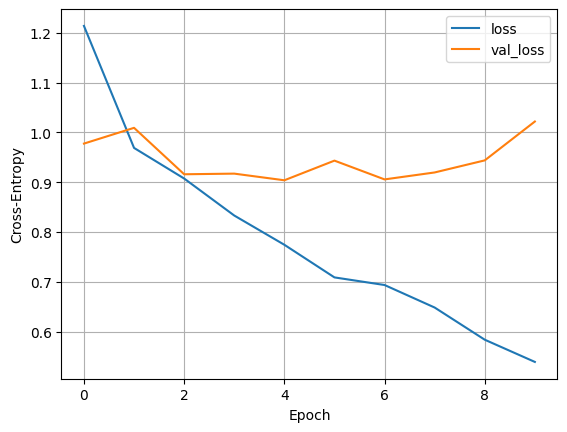

In [ ]:
# Plotting loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.grid(True)

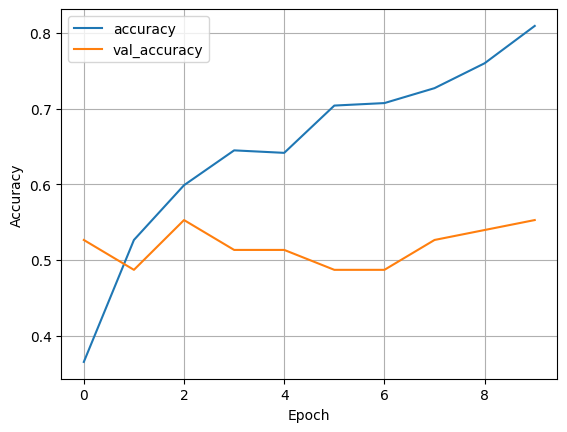

In [ ]:
# Plotting accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:
# Making predictions for the test set
test_probs: np.array = model.predict(val_ds)
# Converting probabilities into specific predictions
test_preds: np.array = np.argmax(test_probs, axis=1)

1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

KeyboardInterrupt: 

In [ ]:
# Extracting y_test

# Unpack batch labels from val_ds
y_test_batches: list[np.ndarray] = [y for x, y in val_ds]
# Concatonate batches
y_test: np.ndarray = np.concatenate(y_test_batches)

## Analysis

In [ ]:
# Examining scores
class_names: list[str] = ['Healthy', 'Not Healthy']

print(classification_report(y_test, test_preds, target_names=class_names))

              precision    recall  f1-score   support

     Healthy       0.79      0.86      0.83        44
 Not Healthy       0.79      0.69      0.73        32

    accuracy                           0.79        76
   macro avg       0.79      0.78      0.78        76
weighted avg       0.79      0.79      0.79        76



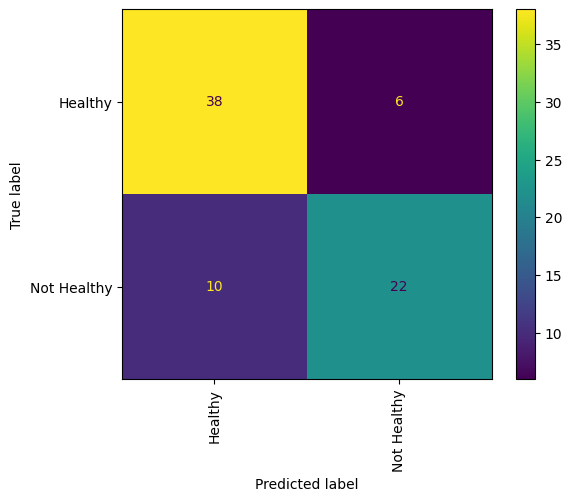

In [ ]:
# Displaying confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=test_preds,
    display_labels=class_names,
    xticks_rotation='vertical'
);

Let's take a look at some of it's predictions

In [ ]:
# Visualizing first 40 predictions
num_vis: int = 40

# Extracting images
batched_test_images: list[np.ndarray] = [X_batch for X_batch, y_batch in val_ds]
test_images: np.ndarray = np.concatenate(batched_test_images)

plt.figure(figsize=(int(num_vis/3),int(num_vis/2)))
columns=5

for i in range(num_vis):
    plt.subplot(int(num_vis/columns), columns, i+1)
    plt.imshow(test_images[i].astype('uint8'), cmap='gray')
    pred: int = test_preds[i]
    true: int = y_test[i]
    colour = 'green' if pred == true else 'red'
    plt.title(f'Pred: {class_names[pred]}\nTrue: {class_names[true]}', color=colour)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# __EXPERIMENT ResNet-50__

Goals:

Changes Made:


In [ ]:
IMG_SHAPE = (256, 256, 3)

In [ ]:
# --- Image Augmentor ----
data_augmentor = keras.Sequential([
    # Randomized augmentations
    layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomContrast(factor=1, seed=RANDOM_SEED),
], name='augmentation_block')

Pretrained models often require specific preprocessing that may be different from the min max scaling we've been doing. Luckily keras also has preprocessors for these models ready to import. We can use a Lambda layer to turn that preprocessing into a keras layer so we can put it inside the pipeline.

In [ ]:
# --- Preprocessor ---
# Preprocessing for EfficientNet architecture
preprocessor = layers.Lambda(efficientnet.preprocess_input, name='preprocessor')

Now we can bring in the pretrained model.

In our case, we just want the model to do the convolutional feature extraction; we'll custom train the classifier to use those features to determine what sign the hands are making. To remove the pretrained classifier from the model so that we can swap in our own we just need to set include_top=False.

We also don't want our optimizer to mess with this model, we want to leave the pretraining and just train a classifier at the end. We can freeze the weights in this part of the model by setting trainable to False; that will make sure AdamW doesn't touch it.

(Note: This code will attempt to make request the model weights from tensorflow's API. If you get a URL fetch failure you can download the model manually instead. The next code cell shows how to do this.)

In [ ]:
from tensorflow.keras.applications import ResNet50
# --- Feature Extractor (also called "The Backbone") ---
feature_extractor = ResNet50(
    input_shape=IMG_SHAPE,
    include_top=False,  # removes the classifier
    weights="/content/drive/MyDrive/InkWell/CNN/pretrained_weights/ResNet50_notop.h5", # path to downloaded .h5 file
    name='efficientnet_backbone'
)

# Freeze weights
feature_extractor.trainable = False

If you get a 403 error trying to access it through the API the easiest alternative is to just download the model manually.

You'll have to download the weights as a .h5 file. You can ask your instructor to post this on the google drive and then download it from there. Don't download it from an untrusted source as it is possible to inject malware into this type of file.

In [ ]:
# --- Classifier (also called "The Head") ---
classifier = keras.Sequential([

    # Flattening input
    #layers.Flatten(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),

    # Dense hidden layer with dropout
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(3, activation='softmax')

], name='classification_head')

In [ ]:
# Combining the modules
model = keras.Sequential([
    layers.Input(shape=IMG_SHAPE),
    data_augmentor, #augmenting before scaling is more efficient
    preprocessor,
    feature_extractor,
    classifier
], name='full_pipeline')

model.summary()

Model: "full_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_block (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessor (Lambda)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_backbone           │ (None, 8, 8, 2048)     │    23,587,712 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 3)              │       262,659 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Training

In [ ]:
# Initializing early stopping
es = EarlyStopping(
    monitor='val_loss',
    patience=5, #number of epochs of no improvement before training is stopped
    restore_best_weights=True #revert weights back to what they were before the plateau (undo overfitting)
)

In [ ]:
# Initializing AdamW with weight decay
adamw_optimizer = AdamW(
    learning_rate=1e-6,
    weight_decay=1e-4,
)

In [ ]:
# Compile model with new optimizer
model.compile(
    optimizer=adamw_optimizer,
    loss='sparse_categorical_crossentropy', #for multiclass problems
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=60, #maximum epochs, may stop before this now that we have early stopping
    validation_data=val_ds,
    callbacks=[es]
)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 65s 10s/step - accuracy: 0.2966 - loss: 1.9724 - val_accuracy: 0.3684 - val_loss: 1.2854
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.3224 - loss: 2.0801 - val_accuracy: 0.3684 - val_loss: 1.2823
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 57s 10s/step - accuracy: 0.3209 - loss: 1.9263 - val_accuracy: 0.3684 - val_loss: 1.2794
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.3006 - loss: 1.8793 - val_accuracy: 0.3553 - val_loss: 1.2764
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 61s 11s/step - accuracy: 0.3242 - loss: 2.1170 - val_accuracy: 0.3553 - val_loss: 1.2735
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 57s 10s/step - accuracy: 0.3058 - loss: 1.9729 - val_accuracy: 0.3553 - val_loss: 1.2707
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 58s 10s/step - accuracy: 0.3177 - loss: 2.0300 - val_accuracy: 0.3553 - val_loss: 1.2678
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.2838 - loss: 2.0680 - val_accuracy: 0.3553 - val_loss: 1.2652


KeyboardInterrupt: 

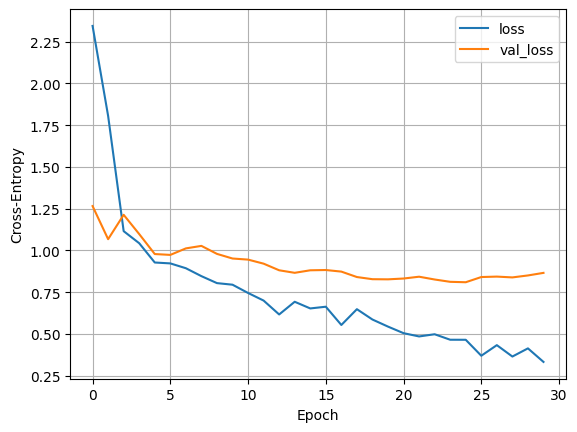

In [ ]:
# Plotting loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.grid(True)

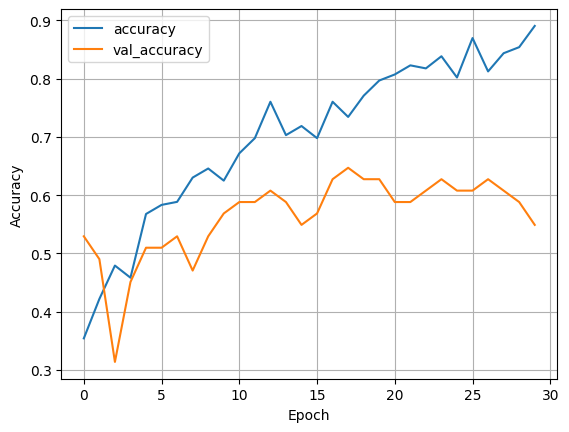

In [ ]:
# Plotting accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:
# Making predictions for the test set
test_probs: np.array = model.predict(val_ds)
# Converting probabilities into specific predictions
test_preds: np.array = np.argmax(test_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [ ]:
# Extracting y_test

# Unpack batch labels from val_ds
y_test_batches: list[np.ndarray] = [y for x, y in val_ds]
# Concatonate batches
y_test: np.ndarray = np.concatenate(y_test_batches)

## Analysis

In [ ]:
# Examining scores
class_names: list[str] = ['Healthy', 'Healing Normally', 'Not Healthy']

print(classification_report(y_test, test_preds, target_names=class_names))

                  precision    recall  f1-score   support

         Healthy       0.56      0.42      0.48        12
Healing Normally       0.44      0.57      0.50        14
     Not Healthy       0.75      0.72      0.73        25

        accuracy                           0.61        51
       macro avg       0.58      0.57      0.57        51
    weighted avg       0.62      0.61      0.61        51



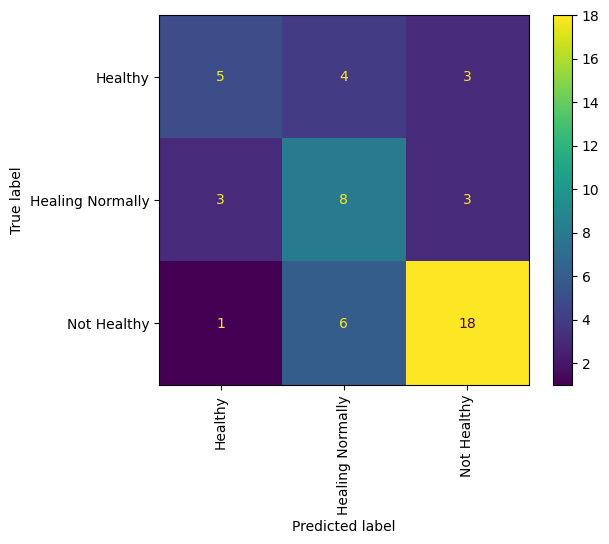

In [ ]:
# Displaying confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=test_preds,
    display_labels=class_names,
    xticks_rotation='vertical'
);

Let's take a look at some of it's predictions

In [ ]:
# Visualizing first 40 predictions
num_vis: int = 40

# Extracting images
batched_test_images: list[np.ndarray] = [X_batch for X_batch, y_batch in val_ds]
test_images: np.ndarray = np.concatenate(batched_test_images)

plt.figure(figsize=(int(num_vis/3),int(num_vis/2)))
columns=5

for i in range(num_vis):
    plt.subplot(int(num_vis/columns), columns, i+1)
    plt.imshow(test_images[i].astype('uint8'), cmap='gray')
    pred: int = test_preds[i]
    true: int = y_test[i]
    colour = 'green' if pred == true else 'red'
    plt.title(f'Pred: {class_names[pred]}\nTrue: {class_names[true]}', color=colour)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# __EXPERIMENT DenseNet121__

In [ ]:
IMG_SHAPE = (224, 224, 3)

In [ ]:
# --- Image Augmentor ----
data_augmentor = keras.Sequential([
    # Randomized augmentations
    layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomContrast(factor=1, seed=RANDOM_SEED),
], name='augmentation_block')

Pretrained models often require specific preprocessing that may be different from the min max scaling we've been doing. Luckily keras also has preprocessors for these models ready to import. We can use a Lambda layer to turn that preprocessing into a keras layer so we can put it inside the pipeline.

In [ ]:
# --- Preprocessor ---
# Preprocessing for EfficientNet architecture
preprocessor = layers.Lambda(mobilenet_v2.preprocess_input, name='preprocessor')

# preprocessor = tf.keras.applications.mobilenet_v2.preprocess_input, name= 'preprocessor'

Now we can bring in the pretrained model.

In our case, we just want the model to do the convolutional feature extraction; we'll custom train the classifier to use those features to determine what sign the hands are making. To remove the pretrained classifier from the model so that we can swap in our own we just need to set include_top=False.

We also don't want our optimizer to mess with this model, we want to leave the pretraining and just train a classifier at the end. We can freeze the weights in this part of the model by setting trainable to False; that will make sure AdamW doesn't touch it.

(Note: This code will attempt to make request the model weights from tensorflow's API. If you get a URL fetch failure you can download the model manually instead. The next code cell shows how to do this.)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
# --- Feature Extractor (also called "The Backbone") ---
feature_extractor = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # removes the classifier
    weights="/content/drive/MyDrive/InkWell/CNN/pretrained_weights/MobileNetV2_notop.h5", # path to downloaded .h5 file
    name='efficientnet_backbone'
)

# Freeze weights
feature_extractor.trainable = False

If you get a 403 error trying to access it through the API the easiest alternative is to just download the model manually.

You'll have to download the weights as a .h5 file. You can ask your instructor to post this on the google drive and then download it from there. Don't download it from an untrusted source as it is possible to inject malware into this type of file.

In [ ]:
# --- Classifier (also called "The Head") ---
classifier = keras.Sequential([

    # Flattening input
    #layers.Flatten(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),

    # Dense hidden layer with dropout
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(3, activation='softmax')

], name='classification_head')

In [ ]:
# Combining the modules
model = keras.Sequential([
    layers.Input(shape = IMG_SHAPE),
    data_augmentor, #augmenting before scaling is more efficient
    preprocessor,
    feature_extractor,
    classifier
], name='full_pipeline')

model.summary()

Model: "full_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_block (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessor (Lambda)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_backbone           │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 3)              │       164,355 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training

In [ ]:
# Initializing early stopping
es = EarlyStopping(
    monitor='val_loss',
    patience=5, #number of epochs of no improvement before training is stopped
    restore_best_weights=True #revert weights back to what they were before the plateau (undo overfitting)
)

In [ ]:
# Initializing AdamW with weight decay
adamw_optimizer = AdamW(
    learning_rate=1e-6,
    weight_decay=1e-4,
)

In [ ]:
# Compile model with new optimizer
model.compile(
    optimizer=adamw_optimizer,
    loss='sparse_categorical_crossentropy', #for multiclass problems
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=60, #maximum epochs, may stop before this now that we have early stopping
    validation_data=val_ds,
    callbacks=[es]
)

Epoch 1/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.1979 - loss: 2.2147 - val_accuracy: 0.0526 - val_loss: 1.9301
Epoch 2/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 8s/step - accuracy: 0.1677 - loss: 2.3352 - val_accuracy: 0.0526 - val_loss: 1.9208
Epoch 3/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.1505 - loss: 2.4431 - val_accuracy: 0.0526 - val_loss: 1.9117
Epoch 4/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.1911 - loss: 2.3148 - val_accuracy: 0.0658 - val_loss: 1.9025
Epoch 5/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.1490 - loss: 2.4661 - val_accuracy: 0.0658 - val_loss: 1.8933
Epoch 6/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1380 - loss: 2.4068 - val_accuracy: 0.0658 - val_loss: 1.8842
Epoch 7/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1396 - loss: 2.5084 - val_accuracy: 0.0658 - val_loss: 1.8752
Epoch 8/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.1292 - loss: 2.3674 - val_accuracy: 0.0658 - val_loss: 1.8662
Epoch 9/

KeyboardInterrupt: 

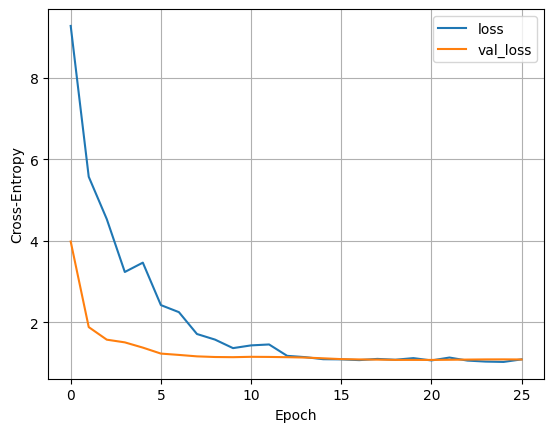

In [ ]:
# Plotting loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.grid(True)

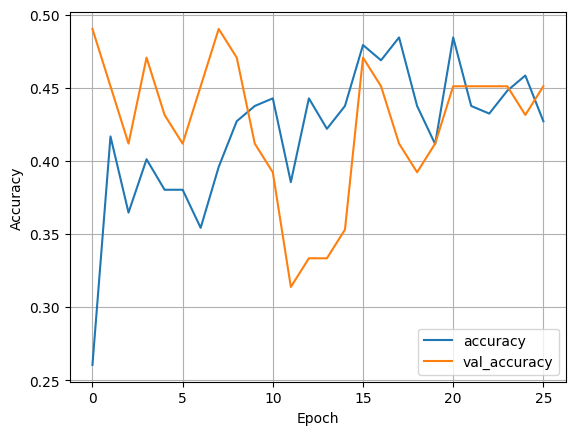

In [ ]:
# Plotting accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:
# Making predictions for the test set
test_probs: np.array = model.predict(val_ds)
# Converting probabilities into specific predictions
test_preds: np.array = np.argmax(test_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


In [ ]:
# Extracting y_test

# Unpack batch labels from val_ds
y_test_batches: list[np.ndarray] = [y for x, y in val_ds]
# Concatonate batches
y_test: np.ndarray = np.concatenate(y_test_batches)

## Analysis

In [ ]:
# Examining scores
class_names: list[str] = ['Healthy', 'Healing Normally', 'Not Healthy']

print(classification_report(y_test, test_preds, target_names=class_names))

                  precision    recall  f1-score   support

         Healthy       0.00      0.00      0.00        12
Healing Normally       0.00      0.00      0.00        14
     Not Healthy       0.47      0.92      0.62        25

        accuracy                           0.45        51
       macro avg       0.16      0.31      0.21        51
    weighted avg       0.23      0.45      0.30        51



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


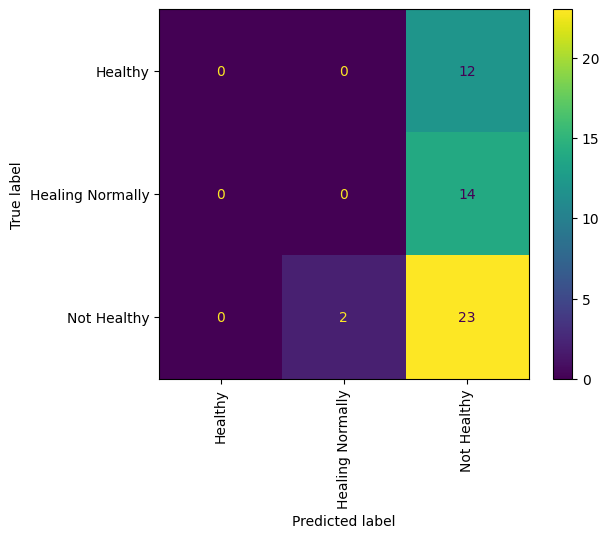

In [ ]:
# Displaying confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=test_preds,
    display_labels=class_names,
    xticks_rotation='vertical'
);

Let's take a look at some of it's predictions

In [ ]:
# Visualizing first 40 predictions
num_vis: int = 40

# Extracting images
batched_test_images: list[np.ndarray] = [X_batch for X_batch, y_batch in val_ds]
test_images: np.ndarray = np.concatenate(batched_test_images)

plt.figure(figsize=(int(num_vis/3),int(num_vis/2)))
columns=5

for i in range(num_vis):
    plt.subplot(int(num_vis/columns), columns, i+1)
    plt.imshow(test_images[i].astype('uint8'), cmap='gray')
    pred: int = test_preds[i]
    true: int = y_test[i]
    colour = 'green' if pred == true else 'red'
    plt.title(f'Pred: {class_names[pred]}\nTrue: {class_names[true]}', color=colour)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Model